# Laboratory Day 3: Filter in spatial domain

## 1. Averaging filter
**Exercise 1.1 (5 points)**:
Apply averaging filters to image '**dog_gray.png**' and visualize the filtered image.

- use kernel size 3*3.

- use kernel size 5*5

- Which kernel has stronger blurring effects?

Please use OpenCV filter2D() function.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
# please do not use other library to solve the exercises in this laboratory.

In [2]:
!git clone https://github.com/Ambos14/ComputerVision26.git

Cloning into 'ComputerVision26'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 56 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 4.37 MiB | 12.07 MiB/s, done.
Resolving deltas: 100% (13/13), done.


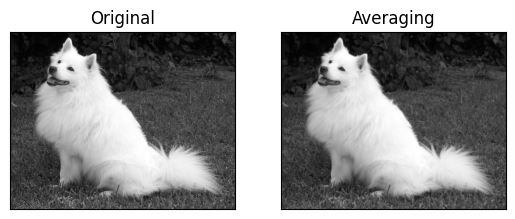

In [3]:
# Solution
img = cv2.imread('/content/ComputerVision26/Praktikum 2/dog_gray.png')
assert img is not None, "file could not be read, check with os.path.exists()"
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img,-1,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

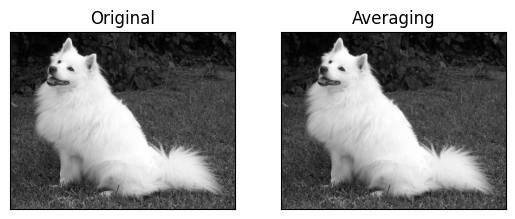

In [4]:
kernel = np.ones((3,3),np.float32)/9
dst = cv2.filter2D(img,-1,kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

The 5x5 Kernel has the stronger blurring effect, because he affects a greater area than the 3x3 Kernel.

## 2. Gaussian filter

**Exercises 2.1 (5 points)**
Given the 2D continuous Gaussian filter formulated as

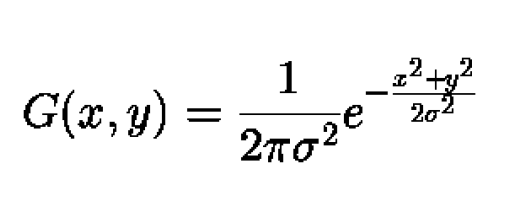

- Write a hand-made function "gauss_kernel(size, sigma)" to compute the discrete/approximated Gaussian kernel in 2D.

- Use this function to compute the Gaussian kernels for (a) kernel size = $5*5$, $\sigma=1$. (b) kernel size=$11*11$, $\sigma=2$

- Use cv2.getGaussianKernel(size, sigma) to get 1D Gaussian kernel.

- Because 2D Gaussian filter is separable, please use cv2.getGaussianKernel() to get 2D Gaussian kernel.

Note:
-  One can use np.mgrid() to discretize the 2D x-y-plane.

-  The sum of all weights of the Gaussian kernel should be equal to 1.

-  Separable filter: https://en.wikipedia.org/wiki/Separable_filter




In [5]:
import numpy as np

def gauss_kernel(size, sigma):
  # Determine the center of the kernel
  center = size // 2

  # Create coordinate system for the 2D kernel
  # x and y will be 2D arrays, each representing the coordinates
  # For a size 5 kernel, coordinates range from -2 to 2
  x, y = np.mgrid[-center : center + 1, -center : center + 1]

  # Apply the 2D Gaussian formula
  # G(x, y) = (1 / (2 * pi * sigma^2)) * e^(-(x^2 + y^2) / (2 * sigma^2))
  # The (1 / (2 * pi * sigma^2)) part is absorbed into normalization later
  kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))

  # Normalize the kernel so that its sum is 1
  kernel /= kernel.sum()

  return kernel

In [6]:
# (a) Using custom gauss_kernel for size = 5, sigma = 1
kernel_5x5_s1 = gauss_kernel(size=5, sigma=1)
print("Custom 5x5 Gaussian Kernel (sigma=1):\n", kernel_5x5_s1)
print("Sum of custom 5x5 kernel elements: ", np.sum(kernel_5x5_s1))

# (b) Using custom gauss_kernel for size = 11, sigma = 2
kernel_11x11_s2 = gauss_kernel(size=11, sigma=2)
print("\nCustom 11x11 Gaussian Kernel (sigma=2):\n", kernel_11x11_s2)
print("Sum of custom 11x11 kernel elements: ", np.sum(kernel_11x11_s2))

Custom 5x5 Gaussian Kernel (sigma=1):
 [[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]
Sum of custom 5x5 kernel elements:  1.0

Custom 11x11 Gaussian Kernel (sigma=2):
 [[7.76553851e-05 2.39195426e-04 5.73799997e-04 1.07199952e-03
  1.55975010e-03 1.76742842e-03 1.55975010e-03 1.07199952e-03
  5.73799997e-04 2.39195426e-04 7.76553851e-05]
 [2.39195426e-04 7.36773780e-04 1.76742842e-03 3.30199100e-03
  4.80436855e-03 5.44406279e-03 4.80436855e-03 3.30199100e-03
  1.76742842e-03 7.36773780e-04 2.39195426e-04]
 [5.73799997e-04 1.76742842e-03 4.23984037e-03 7.92106463e-03
  1.15250810e-02 1.30596277e-02 1.15250810e-02 7.92106463e-03
  4.23984037e-03 1.76742842e-03 5.73799997e-04]
 [1.07199952e-03 3.30199100e-03 7.92106463e-03 1.47984970e-02
  2.153168

In [7]:
# Use cv2.getGaussianKernel() to get 1D Gaussian kernel and combine for 2D

# For size 5x5, sigma=1
kernel_x_5_s1 = cv2.getGaussianKernel(ksize=5, sigma=1)
kernel_y_5_s1 = cv2.getGaussianKernel(ksize=5, sigma=1)
kernel_2D_cv2_5x5_s1 = kernel_x_5_s1 * kernel_y_5_s1.T
print("\nOpenCV 2D Gaussian Kernel (5x5, sigma=1) from 1D kernels:\n", kernel_2D_cv2_5x5_s1)
print("Sum of OpenCV 5x5 kernel elements: ", np.sum(kernel_2D_cv2_5x5_s1))

# For size 11x11, sigma=2
kernel_x_11_s2 = cv2.getGaussianKernel(ksize=11, sigma=2)
kernel_y_11_s2 = cv2.getGaussianKernel(ksize=11, sigma=2)
kernel_2D_cv2_11x11_s2 = kernel_x_11_s2 * kernel_y_11_s2.T
print("\nOpenCV 2D Gaussian Kernel (11x11, sigma=2) from 1D kernels:\n", kernel_2D_cv2_11x11_s2)
print("Sum of OpenCV 11x11 kernel elements: ", np.sum(kernel_2D_cv2_11x11_s2))


OpenCV 2D Gaussian Kernel (5x5, sigma=1) from 1D kernels:
 [[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]
Sum of OpenCV 5x5 kernel elements:  1.0

OpenCV 2D Gaussian Kernel (11x11, sigma=2) from 1D kernels:
 [[7.76553851e-05 2.39195426e-04 5.73799997e-04 1.07199952e-03
  1.55975010e-03 1.76742842e-03 1.55975010e-03 1.07199952e-03
  5.73799997e-04 2.39195426e-04 7.76553851e-05]
 [2.39195426e-04 7.36773780e-04 1.76742842e-03 3.30199100e-03
  4.80436855e-03 5.44406279e-03 4.80436855e-03 3.30199100e-03
  1.76742842e-03 7.36773780e-04 2.39195426e-04]
 [5.73799997e-04 1.76742842e-03 4.23984037e-03 7.92106463e-03
  1.15250810e-02 1.30596277e-02 1.15250810e-02 7.92106463e-03
  4.23984037e-03 1.76742842e-03 5.73799997e-04]
 [1.07199952e-03 3.30199100e-03

**Exercise 2.2 (5 points)**
- Load image "**dog_gray.png**"

- apply Gaussian filter function cv2.GaussianBlur() with size (5, 5) and $sigma=1$ to the image. Display the output.

- apply Gaussian filter function cv2.GaussianBlur() with size (11, 11) and $sigma=2$ to the image. Display the output.







Solutions for Gaussian Blur


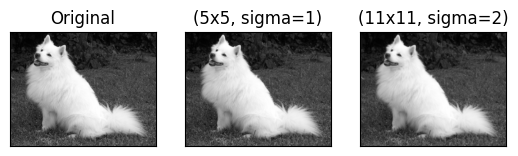

In [8]:
img = cv2.imread('/content/ComputerVision26/Praktikum 2/dog_gray.png')
assert img is not None, "file could not be read, check with os.path.exists()"

# Apply Gaussian filter with size (5, 5) and sigma=1
print("Solutions for Gaussian Blur")
dst_5x5_s1 = cv2.GaussianBlur(img, (5, 5), 1)
plt.subplot(131),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(dst_5x5_s1),plt.title('(5x5, sigma=1)')
plt.xticks([]), plt.yticks([])

# Apply Gaussian filter with size (11, 11) and sigma=2
dst_11x11_s2 = cv2.GaussianBlur(img, (11, 11), 2)
plt.subplot(133),plt.imshow(dst_11x11_s2),plt.title('(11x11, sigma=2)')
plt.xticks([]), plt.yticks([])
plt.show()

## 3. Convolution & Correlation

**Exercise 3.1 (5 points)**
- Run this code to compute the convolution: re_full = np.convolve([1, 2, 3], [0, 1, 0.5], mode='full')
- Compute re_full by yourself. For example, re_full[0] = 1*? + ?*? + ?*? + ..... , re_full[1] = ....

- Run this code to compute the convolution: re_valid = np.convolve([1, 2, 3], [0, 1, 0.5], mode='valid')
- Compute re_valid by yourself, i.e. re_valid = ?*? + ?*? + ...

Note: Please write down the calculation explicitly so that it is understood how the results are computed.

**Die Faustregel**

Wenn du zwei Arrays hast, $a$ (Länge $N$) und $v$ (Länge $M$):

Mode full: Das Ergebnis hat die Länge $N + M - 1$.

Mode valid: Das Ergebnis hat die Länge $max(M, N) - min(M, N) + 1$.

In [9]:
# Solution for Exercise 3.1

# Define the input arrays
a = [1, 2, 3]
k = [0, 1, 0.5]

# Compute convolution with mode='full'
re_full = np.convolve(a, k, mode='full')
print("Convolution (mode='full'):", re_full)

# Compute convolution with mode='valid'
re_valid = np.convolve(a, k, mode='valid')
print("Convolution (mode='valid'):", re_valid)

Convolution (mode='full'): [0.  1.  2.5 4.  1.5]
Convolution (mode='valid'): [2.5]


### Manual Convolution Calculation in Python (mode='full')

In [10]:
# Define the input arrays
a = np.array([1, 2, 3])
k = np.array([0, 1, 0.5])

# For convolution, the kernel k is first flipped
k_flipped = np.flip(k) # k_flipped = [0.5, 1, 0]

# The output length for mode='full' is len(a) + len(k) - 1 = 3 + 3 - 1 = 5
output_len_full = len(a) + len(k) - 1
re_full_manual = np.zeros(output_len_full)

# Manual calculation for 'full' mode
print("Manual calculation for mode='full':")

# re_full_manual[0]: (Aligning a[0] with k_flipped[2] = 0)
re_full_manual[0] = a[0] * k_flipped[2] # 1 * 0
print(f"re_full_manual[0] = {a[0]} * {k_flipped[2]} = {re_full_manual[0]}")

# re_full_manual[1]: (Aligning a[0] with k_flipped[1] = 1, a[1] with k_flipped[2] = 0)
re_full_manual[1] = a[0] * k_flipped[1] + a[1] * k_flipped[2] # 1 * 1 + 2 * 0
print(f"re_full_manual[1] = {a[0]} * {k_flipped[1]} + {a[1]} * {k_flipped[2]} = {re_full_manual[1]}")

# re_full_manual[2]: (Full overlap: a[0] with k_flipped[0] = 0.5, a[1] with k_flipped[1] = 1, a[2] with k_flipped[2] = 0)
re_full_manual[2] = a[0] * k_flipped[0] + a[1] * k_flipped[1] + a[2] * k_flipped[2] # 1 * 0.5 + 2 * 1 + 3 * 0
print(f"re_full_manual[2] = {a[0]} * {k_flipped[0]} + {a[1]} * {k_flipped[1]} + {a[2]} * {k_flipped[2]} = {re_full_manual[2]}")

# re_full_manual[3]: (Aligning a[1] with k_flipped[0] = 0.5, a[2] with k_flipped[1] = 1)
re_full_manual[3] = a[1] * k_flipped[0] + a[2] * k_flipped[1] # 2 * 0.5 + 3 * 1
print(f"re_full_manual[3] = {a[1]} * {k_flipped[0]} + {a[2]} * {k_flipped[1]} = {re_full_manual[3]}")

# re_full_manual[4]: (Aligning a[2] with k_flipped[0] = 0.5)
re_full_manual[4] = a[2] * k_flipped[0] # 3 * 0.5
print(f"re_full_manual[4] = {a[2]} * {k_flipped[0]} = {re_full_manual[4]}")

print("\nFinal re_full_manual:", re_full_manual)


Manual calculation for mode='full':
re_full_manual[0] = 1 * 0.0 = 0.0
re_full_manual[1] = 1 * 1.0 + 2 * 0.0 = 1.0
re_full_manual[2] = 1 * 0.5 + 2 * 1.0 + 3 * 0.0 = 2.5
re_full_manual[3] = 2 * 0.5 + 3 * 1.0 = 4.0
re_full_manual[4] = 3 * 0.5 = 1.5

Final re_full_manual: [0.  1.  2.5 4.  1.5]


### Manual Convolution Calculation in Python (mode='valid')

In [11]:
# Define the input arrays
a = np.array([1, 2, 3])
k = np.array([0, 1, 0.5])

# For convolution, the kernel k is first flipped
k_flipped = np.flip(k) # k_flipped = [0.5, 1, 0]

# The output length for mode='valid' is max(0, len(a) - len(k) + 1) = max(0, 3 - 3 + 1) = 1
output_len_valid = max(0, len(a) - len(k) + 1)
re_valid_manual = np.zeros(output_len_valid)

# Manual calculation for 'valid' mode
print("Manual calculation for mode='valid':")
if output_len_valid > 0:
    # re_valid_manual[0]: (Full overlap: a[0] with k_flipped[0] = 0.5, a[1] with k_flipped[1] = 1, a[2] with k_flipped[2] = 0)
    re_valid_manual[0] = a[0] * k_flipped[0] + a[1] * k_flipped[1] + a[2] * k_flipped[2] # 1 * 0.5 + 2 * 1 + 3 * 0
    print(f"re_valid_manual[0] = {a[0]} * {k_flipped[0]} + {a[1]} * {k_flipped[1]} + {a[2]} * {k_flipped[2]} = {re_valid_manual[0]}")

print("\nFinal re_valid_manual:", re_valid_manual)


Manual calculation for mode='valid':
re_valid_manual[0] = 1 * 0.5 + 2 * 1.0 + 3 * 0.0 = 2.5

Final re_valid_manual: [2.5]


**Exercise 3.2 (5 points)**
- Run this code to compute the correlation: re_full = np.correlate([2, 5, 6], [1, 4, 6, 7], mode='full')
- Compute re_full by yourself. For example, re_full[0] = 1*? + ?? + ?? + ..... , re_full[1] = ....
- Run this code to compute the correlation: re_valid = np.correlate([2, 5, 6], [1, 4, 6, 7], mode='valid')
- Compute re_valid by yourself, i.e. re_valid = ?*? + ?*? + ...

1. Die mathematische Formel (1D)Für zwei diskrete Signale (Arrays) $a$ und $v$ ist die Kreuzkorrelation an der Stelle $n$ wie folgt definiert:$$(a \star v)[n] = \sum_{m} \overline{a[m]} \cdot v[n+m]$$

Die Variablen erklärt:

$(a \star v)[n]$: Das Ergebnis (der Korrelationswert) an der Verschiebungsposition

$n$.$\sum_{m}$: Das Summenzeichen. Wir addieren alle Produkte innerhalb des Überlappungsbereichs auf

$a[m]$: Das Template oder der Filter (in NumPy meist das erste Argument). Der Querstrich

$\overline{a}$ steht für die komplexe Konjugation (bei normalen reellen Zahlen wie

$2, 5, 6$ kannst du das ignorieren).$v[n+m]$: Das Signal oder Bild an der durch

$n$ verschobenen Stelle.

In [14]:
# solution
re_full = np.correlate([2,5,6],[1,4,6,7], mode = "full")
print(re_full)

[14 47 80 58 29  6]


In [22]:
# Define the input arrays
a = np.array([2,5,6])
k = np.array([1,4,6,7])


# The output length
output_len_full = len(a) + len(k) - 1
re_full_manual = np.zeros(output_len_full)
print(output_len_full)
print(re_full_manual)

re_full_manual[0] = 2 * 7

re_full_manual[1] = (2*6)+(5*7)

re_full_manual[2] = 2*4 + 5*6 + 6*7

re_full_manual[3] = (2*1) + (5*4) + (6*6)

re_full_manual[4] = 5*1 + 6*4

re_full_manual[5] = 6*1

print("Lösung für re_full_manual")
print(re_full_manual)

6
[0. 0. 0. 0. 0. 0.]
Lösung für re_full_manual
[14. 47. 80. 58. 29.  6.]


In [16]:
re_valid = np.correlate([2,5,6],[1,4,6,7],mode="valid")
print(re_valid)

[80 58]


In [27]:
# Define the input arrays
a = np.array([2,5,6])
k = np.array([1,4,6,7])

# The output length for mode='valid' is max(0, len(a) - len(k) + 1)
output_len_valid = max(0, len(a) - len(k) + 1)
re_valid_manual = np.zeros(2)

re_valid_manual[0] = 2*4 + 5*6 + 6*7

re_valid_manual[1] = 2*1 + 5*4 + 6*6

print("Lösung für re_valid_manual")
print(re_valid_manual)

Lösung für re_valid_manual
[80. 58.]


**Exercise 3.3 (5 points)**
- For a = [0, 1, 2, 3, 4, 5], formulate any non-trivial 1D kernel k with length=5, so that $conv(a, k) = korr(a, k)$. Check the equality using numpy.

- Explain under which condition of k we can have $conv(a, k) = korr(a, k)$?

In [30]:
a = np.array([0, 1, 2, 3, 4, 5])

# Formulate a non-trivial 1D kernel k with length=5 that is symmetric
# For conv(a, k) = korr(a, k), the kernel k must be symmetric.
# np.convolve(a, k) internally flips k, while np.correlate(a, k) does not.
# So, if k is symmetric, reverse(k) = k, and thus conv(a, k) = corr(a, k).
k = np.array([1, 2, 3, 2, 1])

# Compute convolution
conv_result = np.convolve(a, k, mode='full')
print("Convolution result (full mode):", conv_result)

# Compute correlation
corr_result = np.correlate(a, k, mode='full')
print("Correlation result (full mode):", corr_result)

# Check for equality
print("Are convolution and correlation results equal?", np.array_equal(conv_result, corr_result))

Convolution result (full mode): [ 0  1  4 10 18 27 30 26 14  5]
Correlation result (full mode): [ 0  1  4 10 18 27 30 26 14  5]
Are convolution and correlation results equal? True


### Explanation of the condition for `conv(a, k) = korr(a, k)`

Der Hintergrund ist, dass es sich mit Filtern welche symmetrisch sind es egal ist, ob eine correlation oder eine convulution durchgeführt wird.

Dies ist wichtig, da es je nach Laufanwendung und Anwendung im Hintergrund jeweils mit einer convollution oder correlation gearbeitet wird, und wenn die gleichen Filter in unterschiedlichen Umgebungen auf das gleiche Bild unterschiedliche Effekte hätten wäre das schlecht.

Zudem spart die wegname des Umrechenschritts Rechenpower.

**Text fett markieren**# 4. High-pass filter

**Exercise 4.1 (5 points)**: Prewitt filter

- Load image "**rectangular.png**" as a gray-scale image using OpenCV.
- Select one of Prewitt filters to detect the upper and lower edge of the rectangular.
- Display the detected edges.

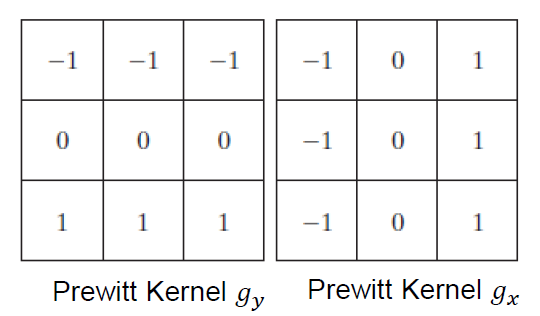

Note that if you get only a single edge, please understand first why the other edge is missing.

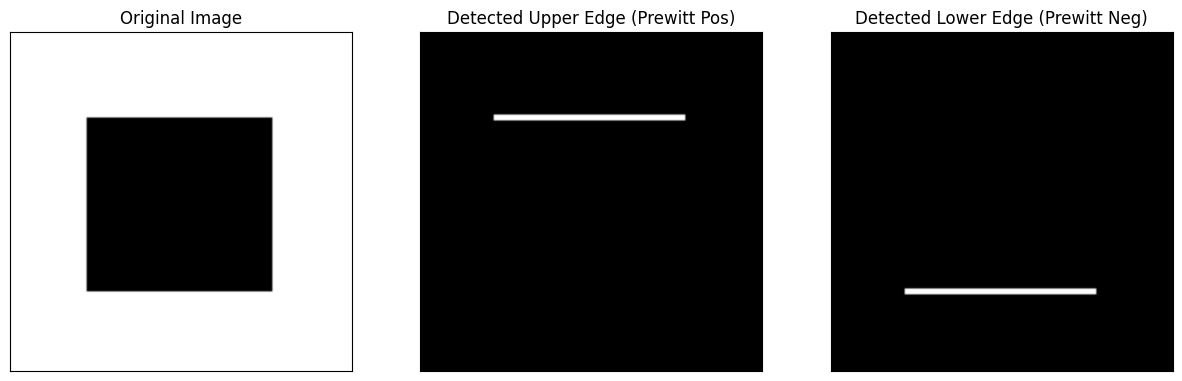

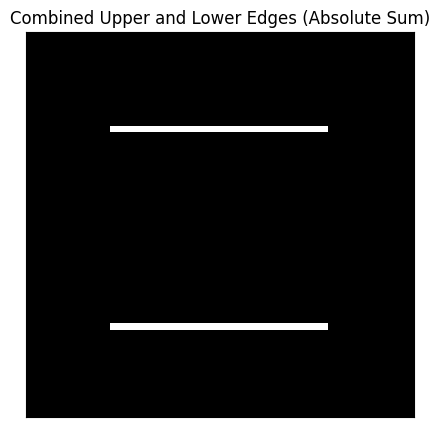

In [32]:
# Load image as grayscale
img_path = '/content/ComputerVision26/Praktikum 2/rectangular.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Check if image loaded successfully
assert img is not None, f"Could not load image at {img_path}. Check path and file."

# Define Prewitt kernels for horizontal edge detection
# Kernel for detecting edges from top to bottom (positive response for transition from dark to light)
prewitt_kernel_h_pos = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# Kernel for detecting edges from bottom to top (positive response for transition from light to dark)
# This is the inverted version of the above, or simply the one that emphasizes the other edge
prewitt_kernel_h_neg = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

# Apply the Prewitt filter (horizontal)
# We'll apply both positive and negative kernels to capture both upper and lower edges clearly
# If we only used one, one edge might be detected strongly and the other weakly or with opposite sign.
# Combining them (e.g., absolute sum) helps to highlight both regardless of gradient direction.
upper_edge = cv2.filter2D(img, -1, prewitt_kernel_h_pos)
lower_edge = cv2.filter2D(img, -1, prewitt_kernel_h_neg)

# To display both edges clearly, we can take the absolute value or combine them
# A simple way to visualize both without sign dependency is to take the absolute value of the response
combined_edges = cv2.addWeighted(cv2.convertScaleAbs(upper_edge), 0.5, cv2.convertScaleAbs(lower_edge), 0.5, 0)

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(upper_edge, cmap='gray')
plt.title('Detected Upper Edge (Prewitt Pos)')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(lower_edge, cmap='gray')
plt.title('Detected Lower Edge (Prewitt Neg)')
plt.xticks([]), plt.yticks([])

plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(combined_edges, cmap='gray')
plt.title('Combined Upper and Lower Edges (Absolute Sum)')
plt.xticks([]), plt.yticks([])
plt.show()


**Exercise 4.2 (5 points)**: Unsharp masking
- Write a function to do "unsharp masking" to a given image. Note that one can use any blurring kernel.
- Load image "**hso_gray.png**" and call this function to get the sharpened image.
- Select proper parameters.  Display the mask and the resulted image.

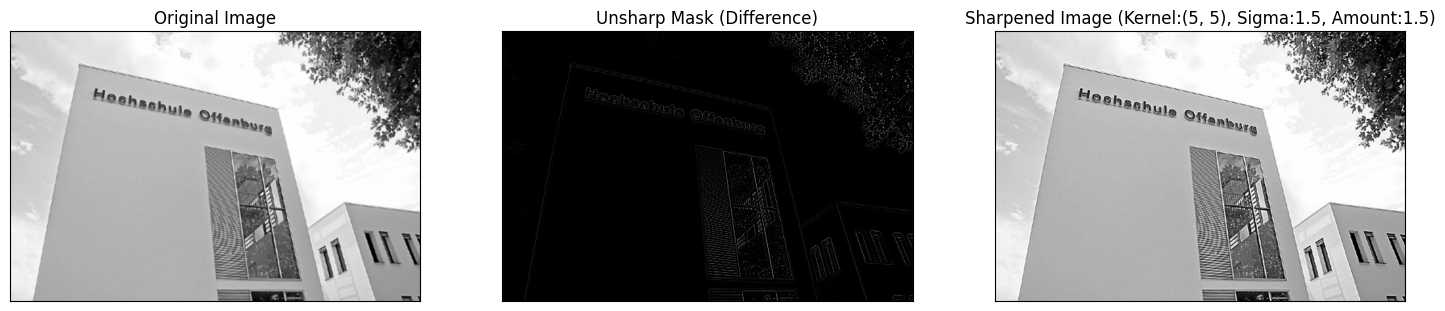

In [34]:
def unsharp_masking(image, blur_kernel_size=(5, 5), sigma=1, amount=1.0):
    """
    Applies unsharp masking to an image.

    Args:
        image (numpy.ndarray): The input grayscale image.
        blur_kernel_size (tuple): Size of the blurring kernel (e.g., (5, 5)).
        sigma (int): Standard deviation of the Gaussian kernel.
        amount (float): The amount of sharpening to apply. Higher values mean more sharpening.

    Returns:
        tuple: A tuple containing the mask and the sharpened image.
    """
    # 1. Blur the original image
    blurred_image = cv2.GaussianBlur(image, blur_kernel_size, sigma)

    # 2. Calculate the unsharp mask
    # The mask is the difference between the original and blurred image
    unsharp_mask = cv2.subtract(image, blurred_image)

    # 3. Add the scaled mask back to the original image
    # The 'amount' parameter controls the strength of sharpening
    sharpened_image = cv2.addWeighted(image, 1.0 + amount, blurred_image, -amount, 0)
    # Clip values to stay within 0-255 range and convert to uint8
    sharpened_image = np.clip(sharpened_image, 0, 255).astype(np.uint8)

    return unsharp_mask, sharpened_image

# Load image as grayscale
img_path = '/content/ComputerVision26/Praktikum 2/hso_gray.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Check if image loaded successfully
assert img is not None, f"Could not load image at {img_path}. Check path and file."

# Select proper parameters for unsharp masking
# blur_kernel_size: needs to be odd. (5,5) is a good starting point.
# sigma: controls the amount of blur. Larger sigma -> more blur, thus sharper mask.
# amount: controls the strength of the sharpening effect. 1.0 is standard.
blur_kernel_size = (5, 5)
sigma = 1.5
amount = 1.5 # Increased amount for a more noticeable sharpening effect

# Call the unsharp_masking function
mask, sharpened_img = unsharp_masking(img, blur_kernel_size, sigma, amount)

# Display the original, mask, and sharpened images
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Unsharp Mask (Difference)')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(sharpened_img, cmap='gray')
plt.title(f'Sharpened Image (Kernel:{blur_kernel_size}, Sigma:{sigma}, Amount:{amount})')
plt.xticks([]), plt.yticks([])

plt.show()